# Inference Batch — Year-wise Mining Detection
**Notebook:** `inference_batch.ipynb`

Runs the same inference pipeline as `inference_visualizer.ipynb` but loops through
every JP2 file year by year automatically.

### What it saves (per year, best scene selected)
```
inference_output/temporal/
  2021_overlay.png          ← satellite + red highlights
  2021_heatmap.png          ← probability heatmap
  2021_result.json          ← mining stats (area, patches, coverage %)
  2022_overlay.png
  2022_heatmap.png
  2022_result.json
  ... (one set per year)
  all_years_results.csv     ← combined table for temporal analysis
```

**Then run `temporal_analysis.ipynb`** which reads these results and makes charts.


## Cell 1 — Imports

In [1]:
import os, glob, re, json
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import pandas as pd
from PIL import Image

import torch
import torch.nn as nn
from torchvision import transforms, models

try:
    import rasterio
    from rasterio.transform import xy as rio_xy
    from rasterio.crs import CRS
    from rasterio.enums import Resampling
    HAS_RASTERIO = True
    print('rasterio OK')
except ImportError:
    HAS_RASTERIO = False
    print('rasterio not found — install: pip install rasterio')

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', device)
if torch.cuda.is_available():
    print('GPU   :', torch.cuda.get_device_name(0))


rasterio OK
Device: cuda
GPU   : NVIDIA GeForce RTX 4060 Laptop GPU


## Cell 2 — Config
> **Only update `DATA_ROOT`** — everything else is auto-detected.

In [2]:
# ── Folder containing your year subfolders ───────────────────────────────
DATA_ROOT = r"R:\ai project image\data image big"

# ── Year folder names → year labels ──────────────────────────────────────
# Add or remove years here to match your actual folders
YEAR_MAP = {
    'big 2021' : 2021,
    '2022'     : 2022,
    '2023'     : 2023,
    '2024'     : 2024,
    '2025'     : 2025,
}

# ── Model ─────────────────────────────────────────────────────────────────
MODEL_PATH  = 'saved_models/best_model.pth'
NUM_CLASSES = 2

# ── Patch settings ────────────────────────────────────────────────────────
PATCH_SIZE  = 64      # training patch size
STRIDE      = 32      # 50% overlap — smoother output
THRESHOLD   = 0.6     # raised — reduces false positives on large scenes
BATCH_SIZE  = 64

# ── Output ────────────────────────────────────────────────────────────────
OUTPUT_DIR  = 'inference_output/temporal'
os.makedirs(OUTPUT_DIR, exist_ok=True)

# ── Scene selection strategy ──────────────────────────────────────────────
# 'max_mining'  : pick scene with highest detected mining area
# 'first'       : always pick the first JP2 in the folder (chronological)
SCENE_SELECT = 'nov_dec'  # pick Nov/Dec scene — same season every year

# ── Max image dimension (downsamples if larger) ───────────────────────────
NATIVE_RES_M = 10.0  # Sentinel-2 10m/px native resolution
MAX_DIM = 5000   # increase if you want higher resolution (uses more RAM)

print(f'Data root  : {DATA_ROOT}')
print(f'Model      : {MODEL_PATH}')
print(f'Output     : {OUTPUT_DIR}')
print(f'Patch size : {PATCH_SIZE}px  Stride: {STRIDE}px  Threshold: {THRESHOLD}')

# Verify year folders exist
for folder, year in sorted(YEAR_MAP.items(), key=lambda x: x[1]):
    path = os.path.join(DATA_ROOT, folder)
    files = glob.glob(os.path.join(path, '*.jp2'))
    status = f'{len(files)} JP2 files' if files else 'NOT FOUND'
    print(f'  {year} ({folder}): {status}')


Data root  : R:\ai project image\data image big
Model      : saved_models/best_model.pth
Output     : inference_output/temporal
Patch size : 64px  Stride: 32px  Threshold: 0.6
  2021 (big 2021): 6 JP2 files
  2022 (2022): 7 JP2 files
  2023 (2023): 6 JP2 files
  2024 (2024): 4 JP2 files
  2025 (2025): 6 JP2 files


## Cell 3 — Load Model

In [3]:
def load_efficientnet_b0(model_path):
    """Load EfficientNet-B0 — matches your training setup exactly."""
    model = models.efficientnet_b0(weights=None)
    in_f  = model.classifier[1].in_features   # 1280
    model.classifier = nn.Sequential(
        nn.Dropout(0.5),
        nn.Linear(in_f, 256),
        nn.ReLU(inplace=True),
        nn.Dropout(0.4),
        nn.Linear(256, NUM_CLASSES)
    )
    state = torch.load(model_path, map_location=device)
    model.load_state_dict(state)
    model.to(device).eval()
    print(f'Model loaded: {model_path}')
    return model

model = load_efficientnet_b0(MODEL_PATH)

# Transform — resize patch to 224x224 for EfficientNet
patch_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])
print('Patch transform ready.')


Model loaded: saved_models/best_model.pth
Patch transform ready.


## Cell 4 — Core Functions
(Same logic as inference_visualizer.ipynb — just packaged as reusable functions)

In [4]:
def load_jp2(path, max_dim=MAX_DIM):
    """Load a Sentinel-2 JP2/GeoTIFF, downsample if too large, return RGB uint8."""
    if HAS_RASTERIO:
        with rasterio.open(path) as src:
            h, w = src.height, src.width
            scale = min(1.0, max_dim / max(h, w))
            nh, nw = int(h * scale), int(w * scale)
            data = src.read(
                out_shape=(src.count, nh, nw),
                resampling=Resampling.bilinear
            )
            geo_transform = src.transform
            crs = src.crs
        # (bands, H, W) → (H, W, 3)
        data = np.moveaxis(data[:3], 0, -1).astype(np.float32)
        for i in range(3):
            p2, p98 = np.percentile(data[:,:,i], (2, 98))
            data[:,:,i] = np.clip((data[:,:,i]-p2)/(p98-p2+1e-8), 0, 1)
        return (data*255).astype(np.uint8), geo_transform, crs, scale
    else:
        img = Image.open(path).convert('RGB')
        img.thumbnail((max_dim, max_dim))
        return np.array(img), None, None, 1.0


def run_inference(img_rgb, patch_size=PATCH_SIZE, stride=STRIDE,
                  threshold=THRESHOLD, batch_size=BATCH_SIZE):
    """
    Sliding window inference. Returns:
      prob_map    : (H,W) float32 — mining probability per pixel
      mining_mask : (H,W) bool    — True where mining detected
      detections  : list of {pixel_y, pixel_x, confidence}
      n_total     : total patches scanned
    """
    H, W = img_rgb.shape[:2]
    prob_map  = np.zeros((H, W), dtype=np.float32)
    count_map = np.zeros((H, W), dtype=np.float32)
    detections = []

    positions = [(y, x)
                 for y in range(0, H - patch_size + 1, stride)
                 for x in range(0, W - patch_size + 1, stride)]

    patches_buf, pos_buf = [], []

    with torch.no_grad():
        for i, (y, x) in enumerate(positions):
            patch = img_rgb[y:y+patch_size, x:x+patch_size]
            patches_buf.append(patch_transform(Image.fromarray(patch)))
            pos_buf.append((y, x))

            flush = (len(patches_buf) == batch_size) or (i == len(positions)-1)
            if flush and patches_buf:
                batch = torch.stack(patches_buf).to(device)
                probs = torch.softmax(model(batch), dim=1)[:, 0].cpu().numpy()

                for (py, px), prob in zip(pos_buf, probs):
                    prob_map [py:py+patch_size, px:px+patch_size] += prob
                    count_map[py:py+patch_size, px:px+patch_size] += 1
                    if prob >= threshold:
                        detections.append({'pixel_y': py, 'pixel_x': px,
                                           'confidence': float(prob)})
                patches_buf, pos_buf = [], []

            if (i+1) % 1000 == 0 or i == len(positions)-1:
                pct = (i+1)/len(positions)*100
                print(f'  {pct:5.1f}%  |  {i+1:,}/{len(positions):,} patches'
                      f'  |  mining so far: {len(detections):,}')

    count_map = np.maximum(count_map, 1)
    prob_map  = prob_map / count_map
    return prob_map, prob_map >= threshold, detections, len(positions)


def make_overlay(img_rgb, mining_mask):
    """Red overlay on detected mining pixels."""
    overlay = img_rgb.copy().astype(np.float32)
    overlay[mining_mask, 0] = np.clip(overlay[mining_mask, 0]*0.4 + 255*0.6, 0, 255)
    overlay[mining_mask, 1] = np.clip(overlay[mining_mask, 1]*0.4,            0, 255)
    overlay[mining_mask, 2] = np.clip(overlay[mining_mask, 2]*0.4,            0, 255)
    return overlay.astype(np.uint8)


def save_overlay_fig(img_rgb, overlay, mining_mask, detections,
                     year, date_str, out_path):
    """Save side-by-side original vs overlay figure."""
    coverage = mining_mask.sum() / mining_mask.size * 100
    fig, axes = plt.subplots(1, 2, figsize=(16, 7))
    axes[0].imshow(img_rgb)
    axes[0].set_title(f'Original — {year} ({date_str})', fontsize=12)
    axes[0].axis('off')
    axes[1].imshow(overlay)
    axes[1].set_title(f'Mining Detection — threshold={THRESHOLD}', fontsize=12)
    axes[1].axis('off')
    red_p  = mpatches.Patch(color='red',  alpha=0.7, label='Mining detected')
    gray_p = mpatches.Patch(color='gray', alpha=0.5, label='Non-mining')
    axes[1].legend(handles=[red_p, gray_p], loc='lower right', fontsize=10)
    axes[1].text(0.02, 0.98,
                 f'Coverage: {coverage:.1f}%\nDetections: {len(detections):,}',
                 transform=axes[1].transAxes, fontsize=10, va='top',
                 bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
    plt.suptitle(f'Illegal Mining Detection — {year}', fontsize=14)
    plt.tight_layout()
    plt.savefig(out_path, dpi=150, bbox_inches='tight')
    plt.close()
    print(f'  Saved overlay: {out_path}')


def save_heatmap_fig(img_rgb, prob_map, year, out_path):
    """Save heatmap figure."""
    fig, axes = plt.subplots(1, 2, figsize=(16, 7))
    axes[0].imshow(img_rgb)
    axes[0].set_title('Original Image', fontsize=12)
    axes[0].axis('off')
    im = axes[1].imshow(prob_map, cmap='RdYlGn_r', vmin=0, vmax=1)
    axes[1].set_title('Mining Confidence Heatmap', fontsize=12)
    axes[1].axis('off')
    plt.colorbar(im, ax=axes[1], fraction=0.046, pad=0.04,
                 label='Mining Probability')
    plt.suptitle(f'Confidence Heatmap — {year}', fontsize=14)
    plt.tight_layout()
    plt.savefig(out_path, dpi=150, bbox_inches='tight')
    plt.close()
    print(f'  Saved heatmap : {out_path}')

print('All functions defined.')


All functions defined.


## Cell 5 — Run Inference Year by Year

This loops through every year folder, processes every JP2, picks the best scene, and saves outputs.

In [5]:
yearly_results = []   # one dict per year (best scene)
all_scenes     = []   # one dict per JP2 file (all scenes)

for folder_name, year in sorted(YEAR_MAP.items(), key=lambda x: x[1]):
    folder_path = os.path.join(DATA_ROOT, folder_name)
    jp2_files   = sorted(glob.glob(os.path.join(folder_path, '*.jp2')))

    if not jp2_files:
        print(f'\n{year}: no JP2 files found in {folder_path} — skipping')
        continue

    print(f'\n{"="*60}')
    print(f'  Year {year}  |  {len(jp2_files)} JP2 file(s)')
    print(f'{"="*60}')

    year_scenes = []

    for jp2_path in jp2_files:
        fname      = os.path.basename(jp2_path)
        date_match = re.search(r'_(\d{8})T', fname)
        date_str   = date_match.group(1) if date_match else 'unknown'
        print(f'\n  [{date_str}] {fname}')

        try:
            # Load image
            img_rgb, geo_tf, crs, scale = load_jp2(jp2_path)
            H, W = img_rgb.shape[:2]
            print(f'  Image size: {W}x{H} px')

            # Run inference
            prob_map, mining_mask, detections, n_total = run_inference(img_rgb)

            n_mining   = len(detections)
            coverage   = mining_mask.sum() / mining_mask.size * 100
            # Area corrected for downsampling scale
            pixel_size_m = NATIVE_RES_M / scale
            mining_pixels = mining_mask.sum()
            area_km2 = (mining_pixels * pixel_size_m**2) / 1e6

            print(f'  Result: {n_mining} mining patches'
                  f'  |  {area_km2:.2f} km²  |  {coverage:.1f}% coverage')

            scene = {
                'year'       : year,
                'date'       : date_str,
                'filename'   : fname,
                'n_mining'   : n_mining,
                'n_total'    : n_total,
                'area_km2'   : area_km2,
                'coverage_pct': coverage,
                # keep arrays for saving figures
                '_img_rgb'     : img_rgb,
                '_prob_map'    : prob_map,
                '_mining_mask' : mining_mask,
                '_detections'  : detections,
            }
            year_scenes.append(scene)
            all_scenes.append(scene)

        except Exception as e:
            print(f'  ERROR: {e}')
            import traceback; traceback.print_exc()

    if not year_scenes:
        continue

    # ── Pick best scene for this year ─────────────────────────────────
    if SCENE_SELECT == 'max_mining':
        best = max(year_scenes, key=lambda s: s['area_km2'])
    elif SCENE_SELECT == 'nov_dec':
        # Same season every year — removes cloud/vegetation seasonal bias
        nov_dec = [s for s in year_scenes if s['date'][4:6] in ('11', '12')]
        if nov_dec:
            best = max(nov_dec, key=lambda s: s['area_km2'])
            print(f'  Nov/Dec scenes: {[s["date"] for s in nov_dec]}')
            print(f'  Selected: {best["date"]} ({best["area_km2"]:.1f} km²)')
        else:
            best = min(year_scenes,
                       key=lambda s: min(abs(int(s['date'][4:6])-11),
                                         abs(int(s['date'][4:6])-12)))
            print(f'  No Nov/Dec found — using closest: {best["date"]}')
    elif SCENE_SELECT == 'median':
        areas_list = [s['area_km2'] for s in year_scenes]
        median_val = sorted(areas_list)[len(areas_list)//2]
        best = min(year_scenes, key=lambda s: abs(s['area_km2'] - median_val))
    else:
        best = year_scenes[0]

    print(f'\n  Best scene for {year}: {best["date"]} '
          f'({best["area_km2"]:.2f} km²)')

    # ── Save overlay + heatmap ────────────────────────────────────────
    overlay = make_overlay(best['_img_rgb'], best['_mining_mask'])

    save_overlay_fig(
        best['_img_rgb'], overlay, best['_mining_mask'],
        best['_detections'], year, best['date'],
        os.path.join(OUTPUT_DIR, f'{year}_overlay.png')
    )
    save_heatmap_fig(
        best['_img_rgb'], best['_prob_map'], year,
        os.path.join(OUTPUT_DIR, f'{year}_heatmap.png')
    )

    # ── Save per-year JSON result (read by temporal_analysis.ipynb) ───
    result_dict = {k: v for k, v in best.items() if not k.startswith('_')}
    json_path = os.path.join(OUTPUT_DIR, f'{year}_result.json')
    with open(json_path, 'w') as f:
        json.dump(result_dict, f, indent=2)

    yearly_results.append(result_dict)

print(f'\n{"="*60}')
print(f'  BATCH INFERENCE COMPLETE')
print(f'  Years processed: {len(yearly_results)}')
print(f'  Total JP2 files: {len(all_scenes)}')
print(f'{"="*60}')



  Year 2021  |  6 JP2 file(s)

  [20210226] T45QUE_20210226T044741_TCI_10m.jp2
  Image size: 5000x5000 px
    4.2%  |  1,000/24,025 patches  |  mining so far: 78
    8.3%  |  2,000/24,025 patches  |  mining so far: 157
   12.5%  |  3,000/24,025 patches  |  mining so far: 217
   16.6%  |  4,000/24,025 patches  |  mining so far: 286
   20.8%  |  5,000/24,025 patches  |  mining so far: 392
   25.0%  |  6,000/24,025 patches  |  mining so far: 477
   29.1%  |  7,000/24,025 patches  |  mining so far: 575
   33.3%  |  8,000/24,025 patches  |  mining so far: 668
   37.5%  |  9,000/24,025 patches  |  mining so far: 745
   41.6%  |  10,000/24,025 patches  |  mining so far: 815
   45.8%  |  11,000/24,025 patches  |  mining so far: 926
   49.9%  |  12,000/24,025 patches  |  mining so far: 1,095
   54.1%  |  13,000/24,025 patches  |  mining so far: 1,325
   58.3%  |  14,000/24,025 patches  |  mining so far: 1,460
   62.4%  |  15,000/24,025 patches  |  mining so far: 1,651
   66.6%  |  16,000/24,02

KeyboardInterrupt: 

## Cell 6 — Save Combined CSV

Saves all results to a single CSV that `temporal_analysis.ipynb` will read.

In [ ]:
# ── All scenes CSV ────────────────────────────────────────────────────────
df_all = pd.DataFrame([
    {k: v for k, v in s.items() if not k.startswith('_')}
    for s in all_scenes
])
df_all = df_all.sort_values(['year','date']).reset_index(drop=True)

all_csv = os.path.join(OUTPUT_DIR, 'all_scenes_results.csv')
df_all.to_csv(all_csv, index=False)
print(f'All scenes saved: {all_csv}')
print(df_all[['year','date','n_mining','area_km2','coverage_pct']].to_string(index=False))

# ── Best-per-year CSV ─────────────────────────────────────────────────────
df_best = pd.DataFrame(yearly_results).sort_values('year').reset_index(drop=True)
df_best['change_km2'] = df_best['area_km2'].diff()
df_best['change_pct'] = df_best['area_km2'].pct_change() * 100

best_csv = os.path.join(OUTPUT_DIR, 'yearly_summary.csv')
df_best.to_csv(best_csv, index=False)
print(f'\nYearly summary saved: {best_csv}')

print(f'\n{"="*55}')
print(f'  YEAR-WISE SUMMARY')
print(f'{"="*55}')
print(f'{"Year":<6} {"Date":<10} {"Patches":<10} {"Area km²":<12} {"Change"}')
print('-'*55)
for _, row in df_best.iterrows():
    chg = (f"{row['change_km2']:+.2f} km² ({row['change_pct']:+.1f}%)"
           if not pd.isna(row.get('change_km2', float('nan'))) and row.get('change_km2') == row.get('change_km2')
           else 'baseline')
    print(f"{int(row['year']):<6} {row['date']:<10} "
          f"{int(row['n_mining']):<10} {row['area_km2']:<12.2f} {chg}")
print('='*55)

print(f'\nAll outputs saved to: {OUTPUT_DIR}/')
print('Now run temporal_analysis.ipynb to generate charts.')


All scenes saved: inference_output/temporal\all_scenes_results.csv
 year     date  n_mining  area_km2  coverage_pct
 2021 20210226      5168 2116.8128     15.966208
 2021 20210328      8256 3381.6576     30.736384
 2021 20210427      6078 2489.5488     20.430848
 2021 20211024       868  355.5328      2.351104
 2021 20211123      1150  471.0400      3.047424
 2021 20211223      5178 2120.9088     16.678912
 2022 20220102      3167 1297.2032      9.097216
 2022 20220412      4682 1917.7472     14.385152
 2022 20220611      4734 1939.0464     16.052224
 2022 20220830       787  322.3552      2.060288
 2022 20220830       787  322.3552      2.060288
 2022 20221029      2527 1035.0592      6.639616
 2022 20221128      3244 1328.7424      9.125888
 2023 20230107      2059  843.3664      5.181440
 2023 20230226      6464 2647.6544     21.811200
 2023 20230328      3897 1596.2112     11.608064
 2023 20230527      4720 1933.3120     15.556608
 2023 20231014       923  378.0608      2.285568
 2

## Cell 7 — Quick Preview: All Overlay Maps Side by Side

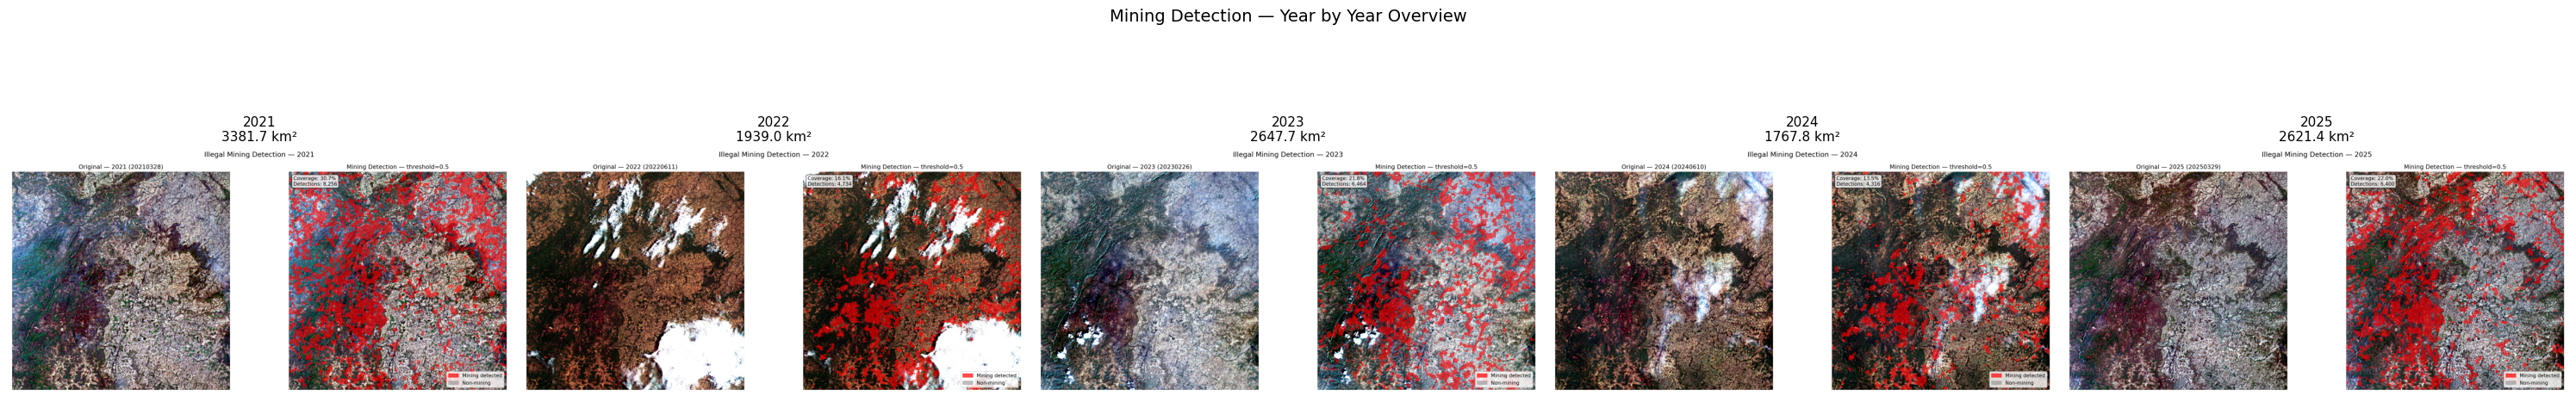

Saved: inference_output/temporal\all_years_overview.png


In [ ]:
if yearly_results:
    n = len(yearly_results)
    fig, axes = plt.subplots(1, n, figsize=(6*n, 6))
    if n == 1: axes = [axes]

    for ax, res in zip(axes, yearly_results):
        img_path = os.path.join(OUTPUT_DIR, f'{res["year"]}_overlay.png')
        if os.path.exists(img_path):
            ax.imshow(plt.imread(img_path))
            ax.set_title(f'{res["year"]}\n{res["area_km2"]:.1f} km²', fontsize=11)
        ax.axis('off')

    plt.suptitle('Mining Detection — Year by Year Overview', fontsize=14)
    plt.tight_layout()
    overview_path = os.path.join(OUTPUT_DIR, 'all_years_overview.png')
    plt.savefig(overview_path, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'Saved: {overview_path}')
